Project: PCA for Chemical Reactor Stability

In this project, we will simulate a chemical reactor where 5 sensors 
(Temperature, Pressure, Flow Rate, Stirrer Speed, and pH) are monitored. 
We will intentionally make Temperature and Pressure highly correlated to see how PCA collapses them into a single "State" component.

1. Generating the Synthetic Data
We will create a dataset where the reactor is "Healthy" for the first 800 observations and starts "Failing" in the last 200.

In [1]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# Generate 1000 observations
n_samples = 1000
time = np.linspace(0, 100, n_samples)

# Simulate "Healthy" sensor data with correlations
# Temperature and Pressure usually move together in a closed vessel
temp = 300 + 5 * np.sin(time/5) + np.random.normal(0, 1, n_samples)
pressure = (temp * 0.5) + np.random.normal(0, 0.5, n_samples) # High correlation
flow_rate = 50 + np.random.normal(0, 2, n_samples)
stirrer_rpm = 1200 + np.random.normal(0, 10, n_samples)
ph_level = 7.0 + np.random.normal(0, 0.1, n_samples)

# Create DataFrame
df = pd.DataFrame({
    'Temp_C': temp,
    'Pressure_kPa': pressure,
    'Flow_m3h': flow_rate,
    'Stirrer_RPM': stirrer_rpm,
    'pH': ph_level
})

# Inject a "Fault" in the last 200 samples (Pressure spike)
df.loc[800:, 'Pressure_kPa'] += 15 
df.loc[800:, 'Temp_C'] += 8

In [2]:
print(df.head(5))

       Temp_C  Pressure_kPa   Flow_m3h  Stirrer_RPM        pH
0  300.496714    150.948035  48.649643  1180.921924  6.913651
1  299.961829    150.443231  49.710963  1191.396150  6.996880
2  300.847835    150.453733  48.415160  1195.863945  7.001802
3  301.823150    150.588106  49.384077  1218.876877  7.047263
4  300.165819    150.432021  46.212771  1205.565531  6.863314


2. The PCA Workflow in Jupyter
Step A: Standardisation
Since RPM (1200) and pH (7.0) are on totally different scales, we must normalise.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

In [4]:
pca = PCA(n_components=2)
pca_results = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(data=pca_results, columns=['PC1', 'PC2'])

3. Visualizing the "Failure"
This is the "Aha!" moment in your notebook. Even though we look at 5 variables, the 2D plot will show a clear split when the fault occurs.

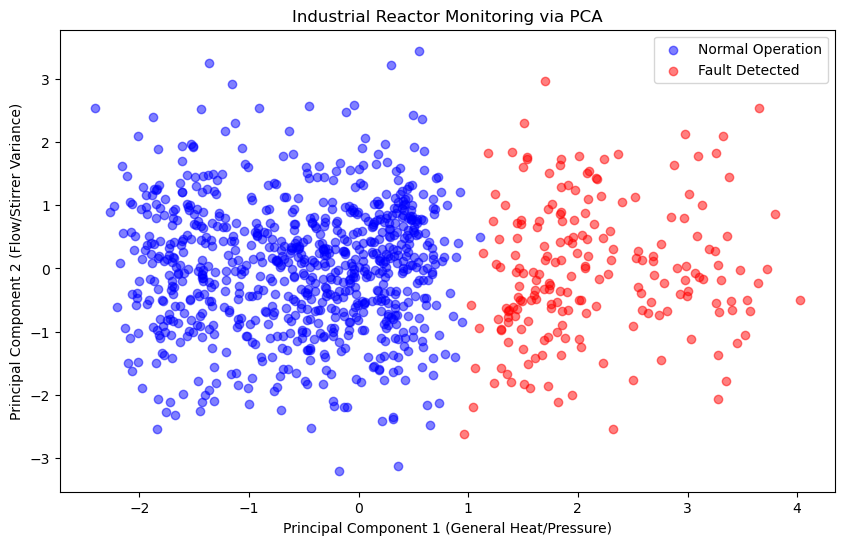

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(df_pca.iloc[:800, 0], df_pca.iloc[:800, 1], c='blue', label='Normal Operation', alpha=0.5)
plt.scatter(df_pca.iloc[800:, 0], df_pca.iloc[800:, 1], c='red', label='Fault Detected', alpha=0.5)
plt.xlabel('Principal Component 1 (General Heat/Pressure)')
plt.ylabel('Principal Component 2 (Flow/Stirrer Variance)')
plt.legend()
plt.title('Industrial Reactor Monitoring via PCA')
plt.show()

4. Interpretation (The Engineering "Why")
In your Jupyter Markdown cells, explain these findings:

Loading Analysis: Check pca.components_. You will likely see that Temp_C and Pressure_kPa have very similar weights on PC1. This proves PCA successfully identified that they represent the same underlying "thermal state" of the reactor.

Dimensionality Reduction: Note that PC1 probably explains >70% of the variance. In a real plant, an engineer could watch just one graph (PC1) instead of five separate dials.